In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import os
import tabix
from scipy.stats import pearsonr, spearmanr
import gzip
from tqdm import tqdm

In [2]:
import rpy2.robjects as ro

During startup - Warning messages:
1: Setting LC_CTYPE failed, using "C" 
2: Setting LC_COLLATE failed, using "C" 
3: Setting LC_TIME failed, using "C" 
4: Setting LC_MESSAGES failed, using "C" 
5: Setting LC_MONETARY failed, using "C" 
6: Setting LC_PAPER failed, using "C" 
7: Setting LC_MEASUREMENT failed, using "C" 


In [8]:
files_list = os.listdir('../code/results/ds_v_dge_confounder/tables/')
comparisons = sorted(set([x.split('.psi.')[0] for x in files_list if '.psi.' in x]))

In [9]:
df1 = pd.read_csv('../code/results/ds_v_dge_confounder/tables/' + comparisons[0] + '.psi.tsv.gz', sep='\t')
df2 = pd.read_csv('../code/results/ds_v_dge_confounder/tables/' + comparisons[1] + '.psi.tsv.gz', sep='\t')

In [10]:
def merge_dataframes(df1, df2):
    df = pd.merge(df1, df2, 
         left_on=['intron', 'cluster', 'itype', 'ctype', 'gene_name', 'gene_id'],
         right_on=['intron', 'cluster', 'itype', 'ctype', 'gene_name', 'gene_id'], how='outer')
    
    if any([x.endswith('_x') for x in df.columns]):
        duplicate_tissues = [x.split('_x')[0] for x in df.columns if x.endswith('_x')]
        
        for tissue in duplicate_tissues:
        
            new_column_data = list(np.array(df[[f'{tissue}_x', f'{tissue}_y']].median(axis=1)))

            df[tissue] = new_column_data#list(np.array(df[[f'{tissue}_x', f'{tissue}_y']].median(axis=1)))
    
    df = df[[x for x in df.columns if not ((x.endswith('_x')) or (x.endswith('_y')))]]
    return df

df = pd.DataFrame(columns = ['intron', 'cluster', 'itype', 'ctype', 'gene_name', 'gene_id'])

for comparison in tqdm(comparisons, position=0, leave=True):
    df_ = pd.read_csv('../code/tmp/ds_v_dge/' + comparison + '.psi.tsv.gz', sep='\t')
    df = merge_dataframes(df, df_)
    

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1225/1225 [20:13<00:00,  1.01it/s]


In [12]:
# compar = [x for x in comparisons if 'WholeBlood' in x]
# for comparison in tqdm(compar, position=0, leave=True):
#     df_ = pd.read_csv('../code/tmp/ds_v_dge/' + comparison + '.psi.tsv.gz', sep='\t')
#     df = merge_dataframes(df, df_)

In [11]:
df

,intron,cluster,itype,ctype,gene_name,gene_id,Artery-Aorta,Brain-Cortex,Brain-Nucleusaccumbens_basalganglia,Esophagus-Muscularis,...,Breast-MammaryTissue,Cells-EBV-transformedlymphocytes,Colon-Sigmoid,Colon-Transverse,Liver,Muscle-Skeletal,Nerve-Tibial,Skin-NotSunExposed_Suprapubic,Skin-SunExposed_Lowerleg,WholeBlood
0,chr10:100185637:100185903:clu_24473_-,chr10:clu_24473_-,PR,PR,ERLIN1,ENSG00000107566.13,0.207438,0.095228,0.184512,0.177740,...,0.221716,0.246375,0.186167,0.280079,0.381064,0.238700,0.221087,0.322134,0.332806,0.459463
1,chr10:100185637:100185961:clu_24473_-,chr10:clu_24473_-,PR,PR,ERLIN1,ENSG00000107566.13,0.792562,0.904772,0.815488,0.822260,...,0.778284,0.753625,0.813833,0.719921,0.618936,0.761300,0.778913,0.677866,0.667194,0.540537
2,chr10:100190968:100192458:clu_24474_-,chr10:clu_24474_-,UP,"PR,UP",CHUK,ENSG00000213341.10,0.083039,0.240722,0.157675,0.087538,...,0.128514,0.025177,0.119784,0.063494,0.030676,0.209774,0.208999,0.158868,0.165861,0.042327
3,chr10:100190968:100193297:clu_24474_-,chr10:clu_24474_-,PR,"PR,UP",CHUK,ENSG00000213341.10,0.898162,0.746643,0.832342,0.897091,...,0.855807,0.964078,0.866662,0.920792,0.960513,0.783437,0.776225,0.824149,0.823942,0.937959
4,chr10:100190968:100193388:clu_24474_-,chr10:clu_24474_-,UP,"PR,UP",CHUK,ENSG00000213341.10,0.018799,0.013974,0.010515,0.015813,...,0.015679,0.010746,0.013979,0.015714,0.009786,0.007655,0.014777,0.017519,0.010528,0.019714
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154676,chrY:6912172:6978212:clu_47894_+,chrY:clu_47894_+,PR,PR,TBL1Y,ENSG00000092377.13,NaN,NaN,NaN,NaN,...,0.245999,NaN,NaN,NaN,NaN,0.280402,NaN,NaN,0.158563,NaN
154677,chrY:6912172:6995803:clu_47894_+,chrY:clu_47894_+,PR,PR,TBL1Y,ENSG00000092377.13,NaN,NaN,NaN,NaN,...,0.021022,NaN,NaN,NaN,NaN,0.017033,NaN,NaN,0.024845,NaN
154678,chrY:6978243:6995803:clu_47894_+,chrY:clu_47894_+,PR,PR,TBL1Y,ENSG00000092377.13,NaN,NaN,NaN,NaN,...,0.244736,NaN,NaN,NaN,NaN,0.264232,NaN,NaN,0.148137,NaN
154679,chrY:6978243:7021448:clu_47894_+,chrY:clu_47894_+,PR,PR,TBL1Y,ENSG00000092377.13,NaN,NaN,NaN,NaN,...,0.169492,NaN,NaN,NaN,NaN,0.162562,NaN,NaN,0.246536,NaN


In [13]:
df.to_csv('GTEx.psi.tsv.gz', sep='\t', header=True, index=False)

In [111]:
df.columns

Index(['intron', 'cluster', 'itype', 'ctype', 'gene_name', 'gene_id',
       'Artery-Aorta', 'Brain-Cortex', 'Brain-Nucleusaccumbens_basalganglia',
       'Esophagus-Muscularis', 'Adipose-Visceral_Omentum', 'AdrenalGland',
       'Artery-Coronary', 'Bladder', 'Brain-Amygdala',
       'Brain-Anteriorcingulatecortex_BA24', 'Brain-Caudate_basalganglia',
       'Brain-CerebellarHemisphere', 'Brain-Cerebellum', 'Brain-Hypothalamus',
       'Brain-Putamen_basalganglia', 'Brain-Spinalcord_cervicalc-1',
       'Brain-Substantianigra', 'Cells-Culturedfibroblasts',
       'Esophagus-GastroesophagealJunction', 'Esophagus-Mucosa',
       'Heart-AtrialAppendage', 'Heart-LeftVentricle', 'Kidney-Cortex', 'Lung',
       'MinorSalivaryGland', 'Ovary', 'Pancreas', 'Pituitary', 'Prostate',
       'SmallIntestine-TerminalIleum', 'Spleen', 'Stomach', 'Testis',
       'Thyroid', 'Uterus', 'Vagina', 'Adipose-Subcutaneous', 'Artery-Tibial',
       'Brain-FrontalCortex_BA9', 'Brain-Hippocampus', 'Breast-Mammar

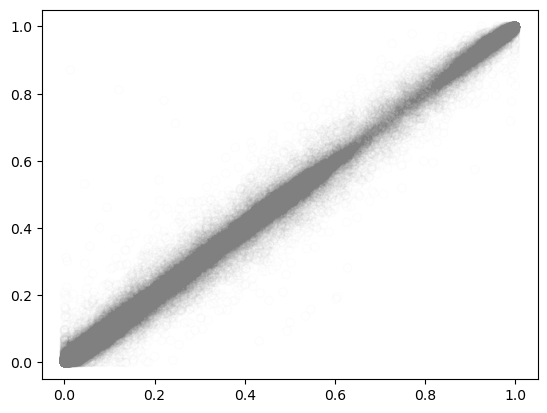

In [113]:
plt.scatter(
    df['Brain-Cortex'],
    df['Brain-FrontalCortex_BA9'], alpha=0.02, edgecolor='gray', facecolor='none')

In [4]:
tissues_ = []
with open('../code/config/tissues.txt') as fh:
    tissues_ = [x.rstrip() for x in fh]

In [7]:
# [x for x in tissues_ if x not in df.columns]

In [8]:
comparisons

['Adipose-Subcutaneous_v_Artery-Tibial',
 'Adipose-Subcutaneous_v_Brain-FrontalCortex_BA9',
 'Adipose-Subcutaneous_v_Brain-Hippocampus',
 'Adipose-Subcutaneous_v_Breast-MammaryTissue',
 'Adipose-Subcutaneous_v_Cells-EBV-transformedlymphocytes',
 'Adipose-Subcutaneous_v_Colon-Sigmoid',
 'Adipose-Subcutaneous_v_Liver',
 'Adipose-Subcutaneous_v_Nerve-Tibial',
 'Adipose-Visceral_Omentum_v_Adipose-Subcutaneous',
 'Adipose-Visceral_Omentum_v_Artery-Tibial',
 'Adipose-Visceral_Omentum_v_Brain-FrontalCortex_BA9',
 'Adipose-Visceral_Omentum_v_Brain-Hippocampus',
 'Adipose-Visceral_Omentum_v_Brain-Hypothalamus',
 'Adipose-Visceral_Omentum_v_Breast-MammaryTissue',
 'Adipose-Visceral_Omentum_v_Cells-EBV-transformedlymphocytes',
 'Adipose-Visceral_Omentum_v_Colon-Sigmoid',
 'Adipose-Visceral_Omentum_v_Colon-Transverse',
 'Adipose-Visceral_Omentum_v_Liver',
 'Adipose-Visceral_Omentum_v_Lung',
 'Adipose-Visceral_Omentum_v_Muscle-Skeletal',
 'Adipose-Visceral_Omentum_v_Nerve-Tibial',
 'Adipose-Viscera

In [88]:
'Brain-Cortex_v_Bladder'

df1 = pd.read_csv('../code/tmp/ds_v_dge/' + 'Brain-Cortex_v_Bladder' + '.psi.tsv.gz', sep='\t')


In [91]:
'Brain-Cortex'.endswith('_x')

False

In [93]:
df.dropna()

,intron,cluster,itype,ctype,gene_name,gene_id,Artery-Aorta,Brain-Nucleusaccumbens_basalganglia,Esophagus-Muscularis,Adipose-Visceral_Omentum,...,Brain-Hippocampus,Breast-MammaryTissue,Cells-EBV-transformedlymphocytes,Colon-Sigmoid,Colon-Transverse,Liver,Muscle-Skeletal,Nerve-Tibial,Skin-NotSunExposed_Suprapubic,Skin-SunExposed_Lowerleg
0,chr10:100185637:100185903:clu_24473_-,chr10:clu_24473_-,PR,PR,ERLIN1,ENSG00000107566.13,0.207766,0.184722,0.178165,0.236358,...,0.179365,0.221716,0.246375,0.186167,0.280079,0.381064,0.238700,0.221087,0.322134,0.332808
1,chr10:100185637:100185961:clu_24473_-,chr10:clu_24473_-,PR,PR,ERLIN1,ENSG00000107566.13,0.792234,0.815278,0.821835,0.763642,...,0.820635,0.778284,0.753625,0.813833,0.719921,0.618936,0.761300,0.778913,0.677866,0.667192
2,chr10:100190968:100192458:clu_24474_-,chr10:clu_24474_-,UP,"PR,UP",CHUK,ENSG00000213341.10,0.082663,0.158239,0.087892,0.081746,...,0.182775,0.128514,0.025177,0.119784,0.063494,0.030676,0.209774,0.208999,0.158865,0.165859
3,chr10:100190968:100193297:clu_24474_-,chr10:clu_24474_-,PR,"PR,UP",CHUK,ENSG00000213341.10,0.899274,0.830619,0.895548,0.906606,...,0.804839,0.855807,0.964078,0.866662,0.920792,0.960513,0.783438,0.776225,0.824144,0.823938
4,chr10:100190968:100193388:clu_24474_-,chr10:clu_24474_-,UP,"PR,UP",CHUK,ENSG00000213341.10,0.018063,0.011142,0.016560,0.013152,...,0.013866,0.015679,0.010746,0.013979,0.015714,0.009787,0.007653,0.014777,0.017520,0.010530
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154547,chrX:85964052:85978766:clu_47601_-,chrX:clu_47601_-,PR,PR,CHM,ENSG00000188419.13,0.920990,0.778858,0.901021,0.862343,...,0.749580,0.921401,0.873514,0.897741,0.890698,0.770259,0.977555,0.871375,0.898778,0.926221
154548,chrX:85971586:85978766:clu_47601_-,chrX:clu_47601_-,PR,PR,CHM,ENSG00000188419.13,0.079010,0.221142,0.098979,0.137657,...,0.250420,0.078599,0.126486,0.102259,0.109302,0.229741,0.022445,0.128625,0.101222,0.073779
154573,chrX:9640360:9653544:clu_46577_+,chrX:clu_46577_+,PR,PR,TBL1X,ENSG00000101849.15,0.378013,0.388636,0.373826,0.354345,...,0.379319,0.335065,0.359216,0.373448,0.348354,0.456791,0.369756,0.346843,0.282958,0.289631
154574,chrX:9640360:9654214:clu_46577_+,chrX:clu_46577_+,PR,PR,TBL1X,ENSG00000101849.15,0.248503,0.183201,0.238029,0.295660,...,0.201951,0.258549,0.298272,0.209272,0.249360,0.076580,0.263469,0.279327,0.408538,0.400953


In [14]:
def merge_dataframes(df1, df2):
    df = pd.merge(df1, df2, 
         left_on=['intron', 'cluster', 'itype', 'ctype', 'gene_name', 'gene_id'],
         right_on=['intron', 'cluster', 'itype', 'ctype', 'gene_name', 'gene_id'], how='outer')
    
    if any([x.endswith('_x') for x in df.columns]):
        duplicate_tissues = [x.split('_x')[0] for x in df.columns if x.endswith('_x')]
        
        for tissue in duplicate_tissues:
        
            new_column_data = list(np.array(df[[f'{tissue}_x', f'{tissue}_y']].median(axis=1)))

            df[tissue] = new_column_data#list(np.array(df[[f'{tissue}_x', f'{tissue}_y']].median(axis=1)))
    
    df = df[[x for x in df.columns if not ((x.endswith('_x')) or (x.endswith('_y')))]]
    return df

def merge_all_dataframes(ext='psi_p'):
    df = pd.DataFrame(columns = ['intron', 'cluster', 'itype', 'ctype', 'gene_name', 'gene_id'])

    for comparison in tqdm(comparisons, position=0, leave=True):
        df_ = pd.read_csv('../code/results/ds_v_dge_confounder/tables/' + comparison + f'.{ext}.tsv.gz', sep='\t')
        df = merge_dataframes(df, df_)
    return df
    

In [10]:
psi_p = merge_all_dataframes(ext='psi_p')

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1225/1225 [36:30<00:00,  1.79s/it]


In [12]:
psi_p.to_csv('GTEx.psi_pvals.tsv.gz', sep='\t', header=True, index=False)

In [17]:
def merge_dataframes(df1, df2):
    df = pd.merge(df1, df2, 
         left_on=['intron', 'cluster', 'itype', 'ctype', 'gene_name', 'gene_id'],
         right_on=['intron', 'cluster', 'itype', 'ctype', 'gene_name', 'gene_id'], how='outer')
    
    if any([x.endswith('_x') for x in df.columns]):
        duplicate_tissues = [x.split('_x')[0] for x in df.columns if x.endswith('_x')]
        
        for tissue in duplicate_tissues:
        
            new_column_data = list(np.array(df[[f'{tissue}_x', f'{tissue}_y']].median(axis=1)))

            df[tissue] = new_column_data#list(np.array(df[[f'{tissue}_x', f'{tissue}_y']].median(axis=1)))
    
    df = df[[x for x in df.columns if not ((x.endswith('_x')) or (x.endswith('_y')))]]
    return df

def merge_all_dataframes(ext='psi_p'):
    df = pd.DataFrame(columns = ['intron', 'cluster', 'itype', 'ctype', 'gene_name', 'gene_id'])

    for comparison in tqdm(comparisons, position=0, leave=True):
        df_ = pd.read_csv('../code/results/ds_v_dge_confounder/tables/' + comparison + f'.{ext}.tsv.gz', sep='\t')
        df = merge_dataframes(df, df_)
    return df
    

In [17]:
sorted(os.listdir('../code/tmp/ds_v_dge/'))

['Adipose-Subcutaneous_v_Artery-Tibial.cluster_counts.tsv.gz',
 'Adipose-Subcutaneous_v_Artery-Tibial.cluster_fraction.tsv.gz',
 'Adipose-Subcutaneous_v_Artery-Tibial.delta_psi.tsv.gz',
 'Adipose-Subcutaneous_v_Artery-Tibial.exp_p.tsv.gz',
 'Adipose-Subcutaneous_v_Artery-Tibial.logFC_exp.tsv.gz',
 'Adipose-Subcutaneous_v_Artery-Tibial.logFC_psi.tsv.gz',
 'Adipose-Subcutaneous_v_Artery-Tibial.psi.tsv.gz',
 'Adipose-Subcutaneous_v_Artery-Tibial.psi_p.tsv.gz',
 'Adipose-Subcutaneous_v_Brain-FrontalCortex_BA9.cluster_counts.tsv.gz',
 'Adipose-Subcutaneous_v_Brain-FrontalCortex_BA9.cluster_fraction.tsv.gz',
 'Adipose-Subcutaneous_v_Brain-FrontalCortex_BA9.delta_psi.tsv.gz',
 'Adipose-Subcutaneous_v_Brain-FrontalCortex_BA9.exp_p.tsv.gz',
 'Adipose-Subcutaneous_v_Brain-FrontalCortex_BA9.logFC_exp.tsv.gz',
 'Adipose-Subcutaneous_v_Brain-FrontalCortex_BA9.logFC_psi.tsv.gz',
 'Adipose-Subcutaneous_v_Brain-FrontalCortex_BA9.psi.tsv.gz',
 'Adipose-Subcutaneous_v_Brain-FrontalCortex_BA9.psi_p.tsv.g

In [14]:
del psi_p

In [18]:
exp_p = merge_all_dataframes(ext='exp_p')

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1225/1225 [37:20<00:00,  1.83s/it]


In [19]:
exp_p.to_csv('GTEx.exp_pvals.tsv.gz', sep='\t', header=True, index=False)

In [20]:
del exp_p

In [18]:
cluster_counts = merge_all_dataframes(ext='cluster_counts')

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1225/1225 [36:05<00:00,  1.77s/it]


In [19]:
cluster_counts.to_csv('GTEx.cluster_counts.tsv.gz', sep='\t', header=True, index=False)

In [23]:
psi_p = pd.read_csv('GTEx.psi_pvals.tsv.gz', sep='\t')

In [131]:
del cluster_counts

In [77]:
with gzip.open('GTEx_cluster.psi_pvals.txt.gz', 'wb') as fh:
    fh.write(('\t'.join(psi_p.columns)+'\n').encode())

    for cluster, df in tqdm(psi_p.groupby('cluster'), position=0, leave=True):
        row_list = [str(x) for x in list(df.min(axis=0))]
        fh.write(('\t'.join(row_list) + '\n').encode())

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 37550/37550 [03:35<00:00, 174.63it/s]


'intron\tcluster\titype\tctype\tgene_name\tgene_id\tAdipose-Subcutaneous_v_Artery-Tibial\tAdipose-Subcutaneous_v_Brain-FrontalCortex_BA9\tAdipose-Subcutaneous_v_Brain-Hippocampus\tAdipose-Subcutaneous_v_Breast-MammaryTissue\tAdipose-Subcutaneous_v_Cells-EBV-transformedlymphocytes\tAdipose-Subcutaneous_v_Colon-Sigmoid\tAdipose-Subcutaneous_v_Liver\tAdipose-Subcutaneous_v_Nerve-Tibial\tAdipose-Visceral_Omentum_v_Adipose-Subcutaneous\tAdipose-Visceral_Omentum_v_Artery-Tibial\tAdipose-Visceral_Omentum_v_Brain-FrontalCortex_BA9\tAdipose-Visceral_Omentum_v_Brain-Hippocampus\tAdipose-Visceral_Omentum_v_Brain-Hypothalamus\tAdipose-Visceral_Omentum_v_Breast-MammaryTissue\tAdipose-Visceral_Omentum_v_Cells-EBV-transformedlymphocytes\tAdipose-Visceral_Omentum_v_Colon-Sigmoid\tAdipose-Visceral_Omentum_v_Colon-Transverse\tAdipose-Visceral_Omentum_v_Liver\tAdipose-Visceral_Omentum_v_Lung\tAdipose-Visceral_Omentum_v_Muscle-Skeletal\tAdipose-Visceral_Omentum_v_Nerve-Tibial\tAdipose-Visceral_Omentum_v_O

In [72]:
[str(x) for x in list(df.min(axis=0))]

['chr10:134786:179993:clu_22961_+',
 'chr10:clu_22961_+',
 'PR',
 'PR',
 'ZMYND11',
 'ENSG00000015171.19',
 '0.638902279922447',
 '6.40543946649367e-28',
 '8.399826242972801e-21',
 '0.505828581920287',
 '5.35246363853627e-30',
 '0.370296768056033',
 '6.48200187300942e-06',
 '0.0023326412282476',
 '0.0610543270329878',
 '0.214630608917727',
 '3.65924415924118e-21',
 '2.3735294601059702e-14',
 '2.09134423768232e-17',
 '0.54381333350927',
 '4.34507436730225e-23',
 '0.0684556880363275',
 '0.960256404190921',
 '0.000489295302527',
 '0.164596815083121',
 '8.04158344662366e-34',
 '0.29820095773133',
 '9.117759338534372e-23',
 '1.33539064229115e-10',
 '2.08381193248218e-10',
 '0.0566951062470077',
 '0.334008273857997',
 '5.10671375387238e-05',
 '0.635340403880376',
 '5.24719623529656e-20',
 '1.88041411154494e-12',
 '1.19643708453051e-12',
 '4.94082215553205e-21',
 '0.000144235407815',
 '8.12919010569048e-05',
 '0.0008766631761898',
 '0.0017271633338629',
 '9.80906252787005e-13',
 '1.9864512093

In [64]:
list(df.min(axis=0))[10:]

[np.float64(5.35246363853627e-30),
 np.float64(0.370296768056033),
 np.float64(6.48200187300942e-06),
 np.float64(0.0023326412282476),
 np.float64(0.0610543270329878),
 np.float64(0.214630608917727),
 np.float64(3.65924415924118e-21),
 np.float64(2.3735294601059702e-14),
 np.float64(2.09134423768232e-17),
 np.float64(0.54381333350927),
 np.float64(4.34507436730225e-23),
 np.float64(0.0684556880363275),
 np.float64(0.960256404190921),
 np.float64(0.000489295302527),
 np.float64(0.164596815083121),
 np.float64(8.04158344662366e-34),
 np.float64(0.29820095773133),
 np.float64(9.117759338534372e-23),
 np.float64(1.33539064229115e-10),
 np.float64(2.08381193248218e-10),
 np.float64(0.0566951062470077),
 np.float64(0.334008273857997),
 np.float64(5.10671375387238e-05),
 np.float64(0.635340403880376),
 np.float64(5.24719623529656e-20),
 np.float64(1.88041411154494e-12),
 np.float64(1.19643708453051e-12),
 np.float64(4.94082215553205e-21),
 np.float64(0.000144235407815),
 np.float64(8.12919010

In [83]:
delta_psi = pd.read_csv('../code/tmp/ds_v_dge/Adipose-Subcutaneous_v_Artery-Tibial.delta_psi.tsv.gz', sep='\t')

In [84]:
pvals_psi = pd.read_csv('../code/tmp/ds_v_dge/Adipose-Subcutaneous_v_Artery-Tibial.psi_p.tsv.gz', sep='\t')

In [87]:
from statsmodels.stats.multitest import fdrcorrection


In [94]:
psi_cluster = pvals_psi.groupby('cluster').min()

In [93]:
pvals_psi.loc[pvals_psi.gene_name == 'SAMD11']

,intron,cluster,itype,ctype,gene_name,gene_id,Adipose-Subcutaneous_v_Artery-Tibial
0,chr1:924948:925921:clu_10_+,chr1:clu_10_+,PR,PR,SAMD11,ENSG00000187634.11,0.120648
1,chr1:925189:925921:clu_10_+,chr1:clu_10_+,PR,PR,SAMD11,ENSG00000187634.11,0.120648
2,chr1:925800:925921:clu_10_+,chr1:clu_10_+,PR,PR,SAMD11,ENSG00000187634.11,0.120648
3,chr1:930336:931038:clu_11_+,chr1:clu_11_+,PR,PR,SAMD11,ENSG00000187634.11,0.764430
4,chr1:930336:935771:clu_11_+,chr1:clu_11_+,PR,PR,SAMD11,ENSG00000187634.11,0.764430
5,chr1:931089:935771:clu_11_+,chr1:clu_11_+,PR,PR,SAMD11,ENSG00000187634.11,0.764430
6,chr1:939129:939271:clu_12_+,chr1:clu_12_+,PR,PR,SAMD11,ENSG00000187634.11,0.152793
7,chr1:939129:939274:clu_12_+,chr1:clu_12_+,PR,PR,SAMD11,ENSG00000187634.11,0.152793
8,chr1:939412:941143:clu_13_+,chr1:clu_13_+,PR,"PR,UP",SAMD11,ENSG00000187634.11,0.000029
9,chr1:939412:942409:clu_13_+,chr1:clu_13_+,PR,"PR,UP",SAMD11,ENSG00000187634.11,0.000029


In [100]:
fdrcorrection(psi_cluster['Adipose-Subcutaneous_v_Artery-Tibial'])[1]

array([7.38955840e-01, 1.61021067e-01, 2.24330040e-12, ...,
       2.57612497e-01, 6.61784082e-01, 4.10251684e-04])

In [101]:
np.sum(fdrcorrection(psi_cluster['Adipose-Subcutaneous_v_Artery-Tibial'])[0])

np.int64(11639)

In [102]:
psi_cluster['q'] = fdrcorrection(psi_cluster['Adipose-Subcutaneous_v_Artery-Tibial'])[1]

In [106]:
psi_cluster

,intron,itype,ctype,gene_name,gene_id,Adipose-Subcutaneous_v_Artery-Tibial,q
cluster,,,,,,,
chr10:clu_22961_+,chr10:134786:179993:clu_22961_+,PR,PR,ZMYND11,ENSG00000015171.19,6.389023e-01,7.389558e-01
chr10:clu_22962_+,chr10:180128:197910:clu_22962_+,NE,"NE,PR",ZMYND11,ENSG00000015171.19,8.774176e-02,1.610211e-01
chr10:clu_22963_+,chr10:210048:221194:clu_22963_+,PR,PR,ZMYND11,ENSG00000015171.19,1.965324e-13,2.243300e-12
chr10:clu_22964_+,chr10:236915:237584:clu_22964_+,PR,PR,ZMYND11,ENSG00000015171.19,3.679149e-08,2.440779e-07
chr10:clu_22965_+,chr10:239525:240055:clu_22965_+,PR,PR,ZMYND11,ENSG00000015171.19,5.735250e-01,6.843519e-01
...,...,...,...,...,...,...,...
chrY:clu_47943_-,chrY:19709809:19710375:clu_47943_-,PR,"PR,UP",KDM5D,ENSG00000012817.15,8.560239e-01,9.026896e-01
chrY:clu_47944_-,chrY:19710472:19715351:clu_47944_-,PR,"PR,UP",KDM5D,ENSG00000012817.15,2.139105e-02,4.891337e-02
chrY:clu_47945_-,chrY:19716004:19716278:clu_47945_-,PR,"PR,UP",KDM5D,ENSG00000012817.15,1.572341e-01,2.576125e-01


In [120]:
pd.Index(delta_psi.loc[delta_psi['Adipose-Subcutaneous_v_Artery-Tibial'].abs() >= 0.1].cluster).intersection(
    psi_cluster.loc[psi_cluster.q <= 5e-2].index
)

Index(['chr1:clu_14_+', 'chr1:clu_29_+', 'chr1:clu_42_+', 'chr1:clu_52_+',
       'chr1:clu_93_+', 'chr1:clu_94_+', 'chr1:clu_104_+', 'chr1:clu_105_+',
       'chr1:clu_171_+', 'chr1:clu_186_+',
       ...
       'chrX:clu_47764_-', 'chrX:clu_47786_-', 'chrX:clu_47802_-',
       'chrX:clu_47814_-', 'chrX:clu_47821_-', 'chrX:clu_47856_-',
       'chrX:clu_47858_-', 'chrX:clu_47876_-', 'chrX:clu_47877_-',
       'chrY:clu_47932_-'],
      dtype='object', name='cluster', length=1810)

In [119]:
psi_cluster.loc[psi_cluster.q <= 5e-2].index

Index(['chr10:clu_22963_+', 'chr10:clu_22964_+', 'chr10:clu_22983_+',
       'chr10:clu_22987_+', 'chr10:clu_22990_+', 'chr10:clu_22991_+',
       'chr10:clu_22994_+', 'chr10:clu_22996_+', 'chr10:clu_22997_+',
       'chr10:clu_22998_+',
       ...
       'chrX:clu_47867_-', 'chrX:clu_47869_-', 'chrX:clu_47876_-',
       'chrX:clu_47877_-', 'chrX:clu_47878_-', 'chrX:clu_47884_-',
       'chrY:clu_47931_-', 'chrY:clu_47932_-', 'chrY:clu_47944_-',
       'chrY:clu_47947_-'],
      dtype='object', name='cluster', length=11639)

In [121]:
cluster_counts

,intron,cluster,itype,ctype,gene_name,gene_id,Adipose-Subcutaneous_v_Artery-Tibial,Adipose-Subcutaneous_v_Brain-FrontalCortex_BA9,Adipose-Subcutaneous_v_Brain-Hippocampus,Adipose-Subcutaneous_v_Breast-MammaryTissue,...,WholeBlood_v_Brain-Hippocampus,WholeBlood_v_Breast-MammaryTissue,WholeBlood_v_Cells-EBV-transformedlymphocytes,WholeBlood_v_Colon-Sigmoid,WholeBlood_v_Colon-Transverse,WholeBlood_v_Liver,WholeBlood_v_Muscle-Skeletal,WholeBlood_v_Nerve-Tibial,WholeBlood_v_Skin-NotSunExposed_Suprapubic,WholeBlood_v_Skin-SunExposed_Lowerleg
0,chr10:100185637:100185903:clu_24473_-,chr10:clu_24473_-,PR,PR,ERLIN1,ENSG00000107566.13,15.0,9.0,8.0,17.0,...,4.0,14.0,18.0,8.0,13.0,8.0,6.0,12.0,12.0,12.0
1,chr10:100185637:100185961:clu_24473_-,chr10:clu_24473_-,PR,PR,ERLIN1,ENSG00000107566.13,15.0,9.0,8.0,17.0,...,4.0,14.0,18.0,8.0,13.0,8.0,6.0,12.0,12.0,12.0
2,chr10:100190968:100192458:clu_24474_-,chr10:clu_24474_-,UP,"PR,UP",CHUK,ENSG00000213341.10,31.0,22.0,21.0,30.0,...,13.0,21.0,37.0,19.0,22.0,14.0,19.0,22.0,17.0,21.0
3,chr10:100190968:100193297:clu_24474_-,chr10:clu_24474_-,PR,"PR,UP",CHUK,ENSG00000213341.10,31.0,22.0,21.0,30.0,...,13.0,21.0,37.0,19.0,22.0,14.0,19.0,22.0,17.0,21.0
4,chr10:100190968:100193388:clu_24474_-,chr10:clu_24474_-,UP,"PR,UP",CHUK,ENSG00000213341.10,31.0,22.0,21.0,30.0,...,13.0,21.0,37.0,19.0,22.0,14.0,19.0,22.0,17.0,21.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154676,chrY:6912172:6978212:clu_47894_+,chrY:clu_47894_+,PR,PR,TBL1Y,ENSG00000092377.13,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
154677,chrY:6912172:6995803:clu_47894_+,chrY:clu_47894_+,PR,PR,TBL1Y,ENSG00000092377.13,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
154678,chrY:6978243:6995803:clu_47894_+,chrY:clu_47894_+,PR,PR,TBL1Y,ENSG00000092377.13,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
154679,chrY:6978243:7021448:clu_47894_+,chrY:clu_47894_+,PR,PR,TBL1Y,ENSG00000092377.13,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [122]:
x = [0, 2, 3, 0, 2, 0]
y = [3, 4, 5, 6, 7, 8]

In [124]:
np.array(y)[np.array(x) == 0]

array([3, 6, 8])

In [126]:
import pandas as pd
import rpy2.robjects as ro
import os
from rpy2.robjects import pandas2ri

rds_file = 'Adipose-Subcutaneous_v_Cells-EBV-transformedlymphocytes.rds'
a_v_b = rds_file.split('.rds')[0]
readRDS = ro.r['readRDS']
rds = readRDS(f'/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/ds_v_dge/{rds_file}')

ds = rds[0]
with (ro.default_converter + pandas2ri.converter).context():
    pd_from_r_df = ro.conversion.get_conversion().rpy2py(ds)
    output = pd_from_r_df
        

During startup - Warning messages:
1: Setting LC_CTYPE failed, using "C" 
2: Setting LC_COLLATE failed, using "C" 
3: Setting LC_TIME failed, using "C" 
4: Setting LC_MESSAGES failed, using "C" 
5: Setting LC_MONETARY failed, using "C" 
6: Setting LC_PAPER failed, using "C" 
7: Setting LC_MEASUREMENT failed, using "C" 


In [127]:
ds

intron,cluster,itype,...,df,p,p.adjust
'chr1:962...,'chr1:clu...,'UP',...,1,0.000011,0.000024
'chr1:962...,'chr1:clu...,'PR',,1,0.000011,0.000024
'chr1:964...,'chr1:clu...,'UP',,1,0.430249,0.492252
'chr1:964...,'chr1:clu...,'PR',,1,0.430249,0.492252
...,...,...,,...,...,...
'chrY:197...,'chrY:clu...,'PR',,6,0.000000,0.000000
'chrY:197...,'chrY:clu...,'PR',,6,0.000000,0.000000
'chrY:197...,'chrY:clu...,'PR',,6,0.000000,0.000000
'chrY:197...,'chrY:clu...,'PR',,6,0.000000,0.000000


In [129]:
import sys
import os
import gzip
import argparse
import numpy as np
import pandas as pd
import rpy2.robjects as ro
import os
from rpy2.robjects import pandas2ri
def process_comparison(rds_file):
    a_v_b = rds_file.split('.rds')[0]
    readRDS = ro.r['readRDS']
    rds = readRDS(f'/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/ds_v_dge/{rds_file}')
    
    ds = rds[0]
    with (ro.default_converter + pandas2ri.converter).context():
        pd_from_r_df = ro.conversion.get_conversion().rpy2py(ds)
        output = pd_from_r_df
        
    dge = rds[1]
    with (ro.default_converter + pandas2ri.converter).context():
        pd_from_r_df = ro.conversion.get_conversion().rpy2py(dge)
        dge = pd_from_r_df
        
    intron_list = []
    cluster_list = []
    tissue1_median_count_list = []
    tissue2_median_count_list = []
    
    tissue1, tissue2 = a_v_b.split('_v_')
    
    with gzip.open(
        f'/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/ds/GTEx/{a_v_b}/ds_perind_numers.counts.noise_by_intron.lf1.gz'
    ) as fh:
        header_lf1 = fh.readline().decode().rstrip().split(' ')#[1:]
        header_tissue1 = np.array([x.startswith(tissue1) for x in header_lf1])
        header_tissue2 = np.array([x.startswith(tissue2) for x in header_lf1])
        for line in fh:
            line = line.decode().rstrip().split(' ')
            intron_list.append(line[0])
            cluster_list.append(line[0].split(':')[0] + ':' + line[0].split(':')[-1])
            
            counts = np.array([int(y) for y in line[1:]])
#             print(header_tissue2)
#             print(header_tissue1)
#             print(counts)
#             print(header_lf1)
#             print(len(counts))
#             print(len(header_tissue1))
#             print(len(header_tissue2))
            tissue1_counts = int(np.median(counts[header_tissue1]))
            tissue2_counts = int(np.median(counts[header_tissue2]))
            
            tissue1_median_count_list.append(tissue1_counts)
            tissue2_median_count_list.append(tissue2_counts)
    
    intron_median_counts = pd.DataFrame()
    intron_median_counts['intron'] = intron_list
    intron_median_counts['cluster'] = cluster_list
    intron_median_counts[tissue1] = tissue1_median_count_list
    intron_median_counts[tissue2] = tissue2_median_count_list
    
    print(output.columns)
    print(output.head())
    
#     median_counts_output = pd.merge(output, intron_median_counts, right_on=['intron', 'cluster'], left_on=['intron', 'cluster'])
    
#     ds = pd.merge(output, intron_median_counts, right_on=['intron', 'cluster'], left_on=['intron', 'cluster'])
    
#     cluster_counts = pd.DataFrame(ds.groupby('cluster').median_counts.sum()).reset_index()
#     cluster_counts.columns = ['cluster', 'cluster_counts']

#     ds = pd.merge(ds, cluster_counts, right_on='cluster', left_on='cluster')

#     dfCluster_max = pd.DataFrame(ds.groupby('gene_id').cluster_counts.max()).reset_index()
#     dfCluster_max.columns = ['gene_id', 'max_cluster_counts']

#     ds = pd.merge(ds, dfCluster_max, left_on='gene_id', right_on='gene_id')
#     ds['cluster_fraction'] = ds.cluster_counts/ds.max_cluster_counts
    
#     ds_dge_table = pd.merge(ds, dge, left_on='gene_id', right_on = 'gene_id').drop_duplicates()
    
#     tissue1, tissue2 = a_v_b.split('_v_')
#     junc_cols = list(ds_dge_table.columns[:6])
    
#     psi_cols = junc_cols + [tissue1, tissue2]
    
#     PSI = ds_dge_table[psi_cols]
    
#     a_v_b_columns = junc_cols + [a_v_b]
    
#     delta_psi = ds_dge_table[junc_cols + ['deltapsi']]
#     logFC_psi = ds_dge_table[junc_cols + ['logef']]
#     logFC_exp = ds_dge_table[junc_cols + ['log2FoldChange']]
#     cluster_counts = ds_dge_table[junc_cols + ['max_cluster_counts']]
#     cluster_fraction = ds_dge_table[junc_cols + ['cluster_fraction']]
#     psi_p = ds_dge_table[junc_cols + ['p']]
#     exp_p = ds_dge_table[junc_cols + ['pvalue']]
        

#     delta_psi.columns = a_v_b_columns
#     logFC_psi.columns = a_v_b_columns
#     logFC_exp.columns = a_v_b_columns
#     cluster_counts.columns = a_v_b_columns
#     cluster_fraction.columns = a_v_b_columns
#     psi_p.columns = a_v_b_columns
#     exp_p.columns = a_v_b_columns
    
    
# #     PSI.to_csv(f'tmp/ds_v_dge/{a_v_b}.psi.tsv.gz', sep='\t', index=False, header=True)
# #     delta_psi.to_csv(f'tmp/ds_v_dge/{a_v_b}.delta_psi.tsv.gz', sep='\t', index=False, header=True)
# #     logFC_psi.to_csv(f'tmp/ds_v_dge/{a_v_b}.logFC_psi.tsv.gz', sep='\t', index=False, header=True)
# #     logFC_exp.to_csv(f'tmp/ds_v_dge/{a_v_b}.logFC_exp.tsv.gz', sep='\t', index=False, header=True)
# #     cluster_counts.to_csv(f'tmp/ds_v_dge/{a_v_b}.cluster_counts.tsv.gz', sep='\t', index=False, header=True)
# #     cluster_fraction.to_csv(f'tmp/ds_v_dge/{a_v_b}.cluster_fraction.tsv.gz', sep='\t', index=False, header=True)
# #     psi_p.to_csv(f'tmp/ds_v_dge/{a_v_b}.psi_p.tsv.gz', sep='\t', index=False, header=True)
# #     exp_p.to_csv(f'tmp/ds_v_dge/{a_v_b}.exp_p.tsv.gz', sep='\t', index=False, header=True)
    
# #     print('success!')



In [130]:
process_comparison('Adipose-Subcutaneous_v_Cells-EBV-transformedlymphocytes.rds')

Index(['intron', 'cluster', 'itype', 'ctype', 'gene_name', 'gene_id', 'logef',
       'Cells-EBV-transformedlymphocytes', 'Adipose-Subcutaneous', 'deltapsi',
       'status', 'loglr', 'df', 'p', 'p.adjust'],
      dtype='object')
                        intron        cluster itype  ctype gene_name  \
1  chr1:962917:963031:clu_14_+  chr1:clu_14_+    UP  PR,UP    KLHL17   
2  chr1:962917:963108:clu_14_+  chr1:clu_14_+    PR  PR,UP    KLHL17   
3  chr1:964167:964348:clu_15_+  chr1:clu_15_+    UP  PR,UP    KLHL17   
4  chr1:964180:964348:clu_15_+  chr1:clu_15_+    PR  PR,UP    KLHL17   
5  chr1:973010:973185:clu_17_+  chr1:clu_17_+    PR     PR   PLEKHN1   

              gene_id     logef  Cells-EBV-transformedlymphocytes  \
1  ENSG00000187961.13 -0.164385                          0.408327   
2  ENSG00000187961.13  0.164385                          0.591673   
3  ENSG00000187961.13  0.027158                          0.554498   
4  ENSG00000187961.13 -0.027158                          0.44

In [132]:
cluster_counts = merge_all_dataframes(ext='cluster_counts_per_tissue')

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1225/1225 [18:20<00:00,  1.11it/s]


In [140]:
cluster_counts.to_csv('GTEx.cluster_counts.tsv.gz', sep='\t', header=True, index=False)

In [141]:
psi = pd.read_csv('GTEx.psi.tsv.gz', sep='\t')

In [142]:
psi

,intron,cluster,itype,ctype,gene_name,gene_id,Artery-Aorta,Brain-Cortex,Brain-Nucleusaccumbens_basalganglia,Esophagus-Muscularis,...,Breast-MammaryTissue,Cells-EBV-transformedlymphocytes,Colon-Sigmoid,Colon-Transverse,Liver,Muscle-Skeletal,Nerve-Tibial,Skin-NotSunExposed_Suprapubic,Skin-SunExposed_Lowerleg,WholeBlood
0,chr10:100185637:100185903:clu_24473_-,chr10:clu_24473_-,PR,PR,ERLIN1,ENSG00000107566.13,0.207438,0.095228,0.184512,0.177740,...,0.221716,0.246375,0.186167,0.280079,0.381064,0.238700,0.221087,0.322134,0.332806,0.459463
1,chr10:100185637:100185961:clu_24473_-,chr10:clu_24473_-,PR,PR,ERLIN1,ENSG00000107566.13,0.792562,0.904772,0.815488,0.822260,...,0.778284,0.753625,0.813833,0.719921,0.618936,0.761300,0.778913,0.677866,0.667194,0.540537
2,chr10:100190968:100192458:clu_24474_-,chr10:clu_24474_-,UP,"PR,UP",CHUK,ENSG00000213341.10,0.083039,0.240722,0.157675,0.087538,...,0.128514,0.025177,0.119784,0.063494,0.030676,0.209774,0.208999,0.158868,0.165861,0.042327
3,chr10:100190968:100193297:clu_24474_-,chr10:clu_24474_-,PR,"PR,UP",CHUK,ENSG00000213341.10,0.898162,0.746643,0.832342,0.897091,...,0.855807,0.964078,0.866662,0.920792,0.960513,0.783437,0.776225,0.824149,0.823942,0.937959
4,chr10:100190968:100193388:clu_24474_-,chr10:clu_24474_-,UP,"PR,UP",CHUK,ENSG00000213341.10,0.018799,0.013974,0.010515,0.015813,...,0.015679,0.010746,0.013979,0.015714,0.009786,0.007655,0.014777,0.017519,0.010528,0.019714
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154676,chrY:6912172:6978212:clu_47894_+,chrY:clu_47894_+,PR,PR,TBL1Y,ENSG00000092377.13,NaN,NaN,NaN,NaN,...,0.245999,NaN,NaN,NaN,NaN,0.280402,NaN,NaN,0.158563,NaN
154677,chrY:6912172:6995803:clu_47894_+,chrY:clu_47894_+,PR,PR,TBL1Y,ENSG00000092377.13,NaN,NaN,NaN,NaN,...,0.021022,NaN,NaN,NaN,NaN,0.017033,NaN,NaN,0.024845,NaN
154678,chrY:6978243:6995803:clu_47894_+,chrY:clu_47894_+,PR,PR,TBL1Y,ENSG00000092377.13,NaN,NaN,NaN,NaN,...,0.244736,NaN,NaN,NaN,NaN,0.264232,NaN,NaN,0.148137,NaN
154679,chrY:6978243:7021448:clu_47894_+,chrY:clu_47894_+,PR,PR,TBL1Y,ENSG00000092377.13,NaN,NaN,NaN,NaN,...,0.169492,NaN,NaN,NaN,NaN,0.162562,NaN,NaN,0.246536,NaN
